### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
import torch; torch._dynamo.config.recompile_limit = 64;


In [ ]:
%%capture
!pip install --no-deps --upgrade timm

In [ ]:
from unsloth import FastModel
import torch
from huggingface_hub import snapshot_download

model, processor = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3n-E4B-it",
    dtype = None,
    max_seq_length = 1024,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.3: Fast Gemma3N patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/3.72G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.15G [00:00<?, ?B/s]

...

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

# Gemma 3N can process Text, Vision and Audio!

Let's first experience how Gemma 3N can handle multimodal inputs. We use Gemma 3N's recommended settings of `temperature = 1.0, top_p = 0.95, top_k = 64` but for this example we use `do_sample=False` for ASR.

In [ ]:
from transformers import TextStreamer
def do_gemma_3n_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **processor.apply_chat_template(messages, add_generation_prompt = True, tokenize = True, return_dict = True, return_tensors = "pt").to("cuda"),
        max_new_tokens = max_new_tokens,
        do_sample=False,
        streamer = TextStreamer(processor, skip_prompt = True),
    )

<h3>Let's Evaluate Gemma 3N Baseline Performance on German Transcription</h2>

In [ ]:
import os
from datasets import Dataset, Audio

base_path = "" #

data = []

max_per_class = 1000
counts = {"real": 0, "fake": 0}

for label in ["real", "fake"]:
    folder = os.path.join(base_path, label)
    for fname in os.listdir(folder):
        if fname.lower().endswith(".wav"):
            if counts[label] >= max_per_class:
                break
            data.append({
                "audio": os.path.join(folder, fname),
                "label": 0 if label == "real" else 1
            })
            counts[label] += 1

dataset = Dataset.from_list(data)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
dataset = dataset.shuffle(seed=42)

print(dataset)
print(dataset[0])

test_audio = dataset[0]

label_counts = dataset.to_pandas()["label"].value_counts().to_dict()
print(f"\nNumber of real (0): {label_counts.get(0,0)}")
print(f"Number of fake (1): {label_counts.get(1,0)}")


Dataset({
    features: ['audio', 'label'],
    num_rows: 2000
})
{'audio': {'path': '/content/drive/MyDrive/299A/2025_10_08/fake/LA_T_9537044.wav', 'array': array([ 6.10351562e-05, -3.05175781e-05,  1.22070312e-04, ...,
        4.57763672e-04,  4.27246094e-04,  4.57763672e-04]), 'sampling_rate': 16000}, 'label': 1}

Number of real (0): 1000
Number of fake (1): 1000


In [ ]:
from IPython.display import Audio, display
print(test_audio['label'])
Audio(test_audio['audio']['array'],rate=test_audio['audio']['sampling_rate'])

1


In [ ]:
messages = [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": "You are an assistant that detects deepfakes accurately.",
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "audio", "audio": test_audio['audio']['array']},
                    {"type": "text", "text": "Is this audio real or fake?"}
                ]
            }
        ]

do_gemma_3n_inference(messages, max_new_tokens = 256)

This is **highly likely to be a deepfake**. 

Here's why:

* **Repetitive and Nonsensical:** The string of the same word ("Json") repeated endlessly is a hallmark of AI-generated audio. Real speech patterns are far more varied and natural.
* **Lack of Meaning:** The repetition serves no communicative purpose, which is typical of deepfake audio created for testing or demonstration.
* **Artificial Sound:** While I can't *hear* the audio, the sheer repetition and lack of natural variation strongly suggest it's artificially generated.

Therefore, based on the provided text, I am confident in classifying this as a deepfake.



<end_of_turn>


In [ ]:
messages = [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": "You are an assistant that detects deepfakes accurately. Answer with exactly one word: Real. or Fake. No explanation.",
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "audio", "audio": test_audio['audio']['array']},
                    {"type": "text", "text": "Is this audio real or fake?"}
                ]
            }
        ]

do_gemma_3n_inference(messages, max_new_tokens = 256)

Fake.<end_of_turn>


<h3>Baseline Model Performance: 24.32% Word Error Rate (WER) for this sample !</h3>

# Let's finetune Gemma 3N!

You can finetune the vision and text and audio parts

We now add LoRA adapters so we only need to update a small amount of parameters!

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 8,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    target_modules = [
        "audio_embed",
        "audio_projection",
        "post",
        "linear_start",
        "linear_end",
        "all-linear",
        "embedding_projection",

        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)


Unsloth: Making `model.base_model.model.model.language_model` require gradients


### Data Prep


In [ ]:
def format_intersection_data(samples: dict) -> dict[str, list]:
    """Format dataset for real/fake audio classification"""
    formatted_samples = {"messages": [], "audio": [], "label": []}

    for idx in range(len(samples["audio"])):
        audio = samples["audio"][idx]["array"]
        label_value = samples["label"][idx]

        label_text = "Fake." if label_value == 1 else "Real."

        messages = [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": "You are an assistant that detects deepfakes accurately. Answer with exactly one word: Real. or Fake. No explanation.",
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "audio", "audio": audio},
                    {"type": "text", "text": "Is this audio real or fake?"}
                ]
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": label_text}]
            }
        ]

        formatted_samples["messages"].append(messages)
        formatted_samples["audio"].append(audio)
        formatted_samples["label"].append(label_value)

    return formatted_samples


In [ ]:
dataset = dataset.map(format_intersection_data, batched=True, batch_size=4, num_proc=4)

Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
def collate_fn(examples):
    texts = []
    audios = []
    labels = []
    for example in examples:
        text = processor.apply_chat_template(
            example["messages"], tokenize=False, add_generation_prompt=False
        ).strip()
        texts.append(text)
        audios.append(example["audio"])
        labels.append(example["label"])

    batch = processor(text=texts, audio=audios, return_tensors="pt", padding=True)
    labels_tensor = batch["input_ids"].clone()
    labels_tensor[:] = -100

    for i, label in enumerate(labels):
        answer = "Real." if label == 0 else "Fake."
        answer_ids = processor.tokenizer.encode(answer, add_special_tokens=False)
        ids = batch["input_ids"][i].tolist()
        for j in range(len(ids) - len(answer_ids)):
            if ids[j:j+len(answer_ids)] == answer_ids:
                labels_tensor[i, j:j+len(answer_ids)] = torch.tensor(answer_ids)
                break

    batch["labels"] = labels_tensor
    return batch


<a name="Train"></a>
### Train the model
Now let's train our model. We train for one full epoch (num_train_epochs=1) to get a meaningful result.

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=processor.tokenizer,
    data_collator=collate_fn,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        num_train_epochs = 1,
        learning_rate = 1e-4,
        logging_steps = 10,
        save_strategy = "epoch",
        warmup_ratio = 0.05,
        lr_scheduler_type = "cosine",
        weight_decay = 0.001,
        output_dir = "outputs",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 2,
        max_length = 2048,
        report_to= "none",
    )
)

# Let's train the model!

To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 21,188,608 of 7,871,166,800 (0.27% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,2.215500
20,0.631200
30,0.356000
40,0.457700
50,0.360900
60,0.339700
70,0.533600
80,0.190500
90,0.000000
100,0.666000


<a name="Inference"></a>
### Inference
Let's run the model via Unsloth native inference! According to the `Gemma-3` team, the recommended settings for inference are `temperature = 1.0, top_p = 0.95, top_k = 64` but for this example we use `do_sample=False` for ASR.

In [ ]:
from datasets import Dataset, Audio
import os

data_0 = []
base_path = '/test' #
max_per_class = 500
counts = {"real": 0, "fake": 0}

for label in ["real", "fake"]:
    folder_0 = os.path.join(base_path, label)
    for fname_0 in os.listdir(folder_0):
        if fname_0.lower().endswith((".wav")):
            if counts[label] >= max_per_class:
                break
            data_0.append({
                "audio": os.path.join(folder_0, fname_0),
                "label": 0 if label == 'real' else 1
            })
            counts[label] += 1

dataset0 = Dataset.from_list(data_0)
dataset0 = dataset0.cast_column("audio", Audio(sampling_rate=16000))
dataset0 = dataset0.shuffle(seed=42)
print(dataset0)
print(dataset0[0])

label_counts0 = dataset0.to_pandas()["label"].value_counts().to_dict()
print(f"\nNumber of real (0): {label_counts0.get(0,0)}")
print(f"Number of fake (1): {label_counts0.get(1,0)}")

Dataset({
    features: ['audio', 'label'],
    num_rows: 1000
})
{'audio': {'path': '/content/drive/MyDrive/299A/2025_10_08/test/fake/LA_E_5528243.wav', 'array': array([ 3.05175781e-05,  3.05175781e-05,  3.05175781e-05, ...,
       -3.05175781e-05, -3.05175781e-05, -3.05175781e-05]), 'sampling_rate': 16000}, 'label': 1}

Number of real (0): 500
Number of fake (1): 500


[1/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[2/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[3/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[4/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[5/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[6/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[7/1000] GT: 1 | Pred text: 'real.' | Pred label: 0
[8/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[9/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[10/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[11/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[12/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[13/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[14/1000] GT: 1 | Pred text: 'fake.' | Pred label: 1
[15/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[16/1000] GT: 1 | Pred text: 'real.' | Pred label: 0
[17/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[18/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[19/1000] GT: 0 | Pred text: 'real.' | Pred label: 0
[2

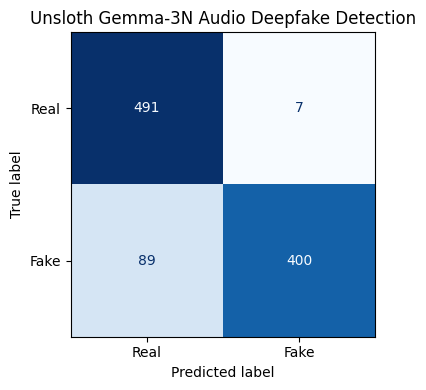


Confusion matrix (Real=0, Fake=1):
 [[491   7]
 [ 89 400]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def do_gemma_3n_inference(messages, max_new_tokens=128):
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    output_tokens = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )


    output_text = processor.batch_decode(output_tokens, skip_special_tokens=True)[0]
    if "model" in output_text.lower():
        output_text = output_text.lower().split("model")[-1].strip()

    return output_text.strip()


y_true, y_pred = [], []

for i, example in enumerate(dataset0):
    messages = [
        {
            "role": "system",
            "content": [
                {"type": "text",
                 "text": "You are an assistant that detects deepfakes accurately. Answer with exactly one word: Real. or Fake. No explanation."}
            ]
        },
        {
            "role": "user",
            "content": [
                {"type": "audio", "audio": example["audio"]["array"]},
                {"type": "text", "text": "Is this audio real or fake?"}
            ]
        }
    ]

    try:
        output = do_gemma_3n_inference(messages, max_new_tokens=256)
        text = output.lower()

        if "fake" in text:
            pred = 1
        elif "real" in text:
            pred = 0
        else:
            print(f"[{i+1}] Unrecognized output:", text)
            continue

        y_true.append(example["label"])  # 0=real, 1=fake
        y_pred.append(pred)

        print(f"[{i+1}/{len(dataset0)}] GT: {example['label']} | Pred text: '{text}' | Pred label: {pred}")

    except Exception as e:
        print(f"Error on sample {i}: {e}")
        continue


cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Unsloth Gemma-3N Audio Deepfake Detection")
plt.tight_layout()
plt.show()

print("\nConfusion matrix (Real=0, Fake=1):\n", cm)


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, pos_label=1, average='binary')
recall = recall_score(y_true, y_pred, pos_label=1, average='binary')
f1 = f1_score(y_true, y_pred, pos_label=1, average='binary')

mcc = matthews_corrcoef(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"--- Classification Metrics for Binary Task (Real=0, Fake=1) ---")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

--- Classification Metrics for Binary Task (Real=0, Fake=1) ---
TP=400, TN=491, FP=7, FN=89
Accuracy: 0.9027
Precision: 0.9828
Recall: 0.8180
F1-Score: 0.8929
MCC: 0.8165


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!